In [3]:
import pandas as pd

data = pd.read_csv('Twitter_Data.csv')

print(data.head())
print(data.columns)
print(data.shape)

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
Index(['clean_text', 'category'], dtype='object')
(139423, 2)


In [4]:
print(data['category'].value_counts())

category
 1.0    61754
 0.0    47204
-1.0    30463
Name: count, dtype: int64


In [10]:
import numpy as np
import pandas as pd
import nltk
import re

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
data.dropna(inplace=True)

print(data.shape)

(139420, 2)


In [8]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [11]:
corpus = []

stop_words = set(stopwords.words('english'))


lemmatizer = WordNetLemmatizer()

for review in data['clean_text']:

    review = re.sub('[^a-zA-Z]', ' ', str(review))
    review = review.lower()

    review_words = review.split()

    review_words = [
        word for word in review_words
        if word not in stop_words
    ]

    review_words = [
        lemmatizer.lemmatize(word)
        for word in review_words
    ]

    corpus.append(' '.join(review_words))

In [12]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(corpus)

y = data['category']

print(X.shape)
print(y.shape)

(139420, 5000)
(139420,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8792856118203988
              precision    recall  f1-score   support

        -1.0       0.87      0.75      0.81      6093
         0.0       0.84      0.96      0.90      9440
         1.0       0.92      0.88      0.90     12351

    accuracy                           0.88     27884
   macro avg       0.88      0.86      0.87     27884
weighted avg       0.88      0.88      0.88     27884



In [17]:
from sklearn.metrics import f1_score

print("Weighted F1 Score:",
      f1_score(y_test, y_pred, average='weighted'))

Weighted F1 Score: 0.877988683795016


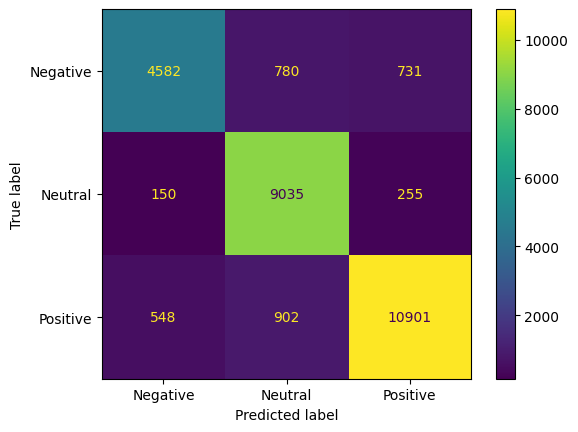

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative",
                    "Neutral",
                    "Positive"]
)

disp.plot()

plt.show()

In [19]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(
    y_test,
    svm_pred
))

SVM Accuracy: 0.8902955099698752
              precision    recall  f1-score   support

        -1.0       0.87      0.79      0.83      6093
         0.0       0.86      0.96      0.91      9440
         1.0       0.93      0.89      0.91     12351

    accuracy                           0.89     27884
   macro avg       0.89      0.88      0.88     27884
weighted avg       0.89      0.89      0.89     27884



In [21]:
pickle.dump(
    model,
    open("twitter_sentiment_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("twitter_tfidf.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [25]:
def predict_sentiment(review):

    review = re.sub('[^a-zA-Z]', ' ', review)
    review = review.lower()

    review_words = review.split()

    review_words = [
        word for word in review_words
        if word not in stop_words
    ]

    review_words = [
        lemmatizer.lemmatize(word)
        for word in review_words
    ]

    review = ' '.join(review_words)

    review_vector = tfidf.transform([review])

    prediction = model.predict(review_vector)[0]

    if prediction == 1:
        return "Positive"

    elif prediction == 0:
        return "Neutral"

    else:
        return "Negative"

In [26]:
print(
    predict_sentiment(
        "I love this government"
    )
)

print(
    predict_sentiment(
        "This is the worst decision ever"
    )
)

print(
    predict_sentiment(
        "I went to office today"
    )
)

Positive
Negative
Neutral


In [27]:
user_review = input("Enter Tweet: ")

result = predict_sentiment(user_review)

if result == "Positive":
    print("😊 Positive")

elif result == "Neutral":
    print("😐 Neutral")

else:
    print("😞 Negative")

Enter Tweet: i really hate it
😞 Negative
